===== TRADE SUMMARY =====
 trade_id entry_date  exit_date     exdate  entry_dte  exit_dte  call_optionid  put_optionid  call_strike  put_strike  entry_call_delta  entry_put_delta  entry_call_mid  entry_put_mid  exit_call_mid  exit_put_mid     trade_pnl
        1 2022-08-29 2022-09-15 2022-09-30         32        15      148915193     148915214         15.0        15.0          0.497931        -0.505672           1.225          1.550          0.750         0.925 -1.500000e+01
        2 2022-09-16 2022-09-29 2022-10-14         28        15      149412453     149412474         15.0        15.0          0.496772        -0.490655           0.975          1.375          2.050         0.375 -2.075000e+02
        3 2022-09-30 2022-10-13 2022-10-28         28        15      149502993     149503014         17.5        17.5          0.493456        -0.497258           1.350          1.925          0.750         1.325  0.000000e+00
        4 2022-10-14 2022-10-27 2022-11-11         28        15   

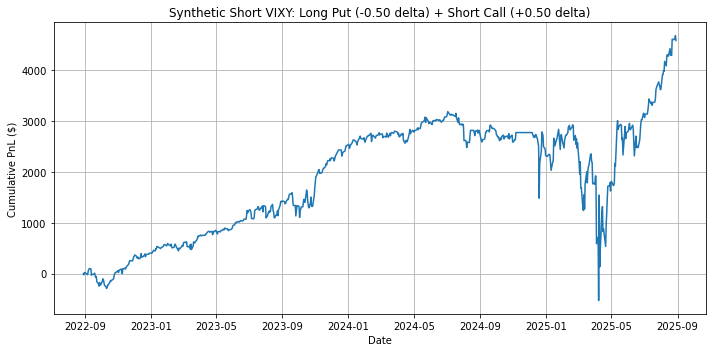

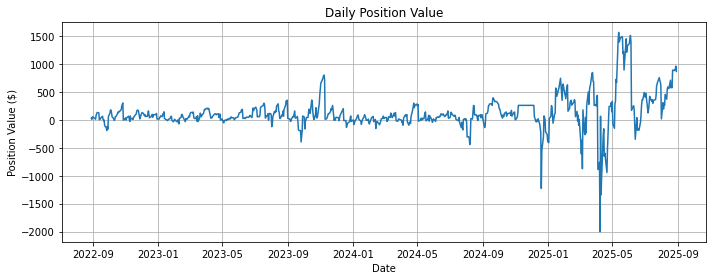

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# VIXY synthetic short using raw option data
# Entry:
#   - buy 1 put with delta closest to -0.50
#   - sell 1 call with delta closest to +0.50
#   - same expiration, target ~30 DTE
#
# Exit / Roll:
#   - hold exact option IDs
#   - roll when remaining DTE <= 7
#
# Assumptions:
#   - use mid price = (best_bid + best_offer)/2
#   - use only standard 100-share contracts
#   - carry forward missing quotes while position is open
#   - ignores commissions / slippage unless you add them
# ============================================================

FILE = "b10xheebr3v3h1vn.csv"

TARGET_DTE = 30
ROLL_DTE = 15 or 10
PUT_TARGET_DELTA = -0.50
CALL_TARGET_DELTA = 0.50
CONTRACTS = 1
MULTIPLIER = 100
COMMISSION_PER_CONTRACT_PER_LEG = 0.00   # e.g. 0.65 if you want
START_DATE = None                        # e.g. "2024-11-15"
END_DATE = None                          # optional


# Load and clean
df = pd.read_csv(FILE, low_memory=False)

df["date"] = pd.to_datetime(df["date"])
df["exdate"] = pd.to_datetime(df["exdate"])

if START_DATE is not None:
    df = df[df["date"] >= pd.to_datetime(START_DATE)].copy()
if END_DATE is not None:
    df = df[df["date"] <= pd.to_datetime(END_DATE)].copy()

# Use standard contracts only
df = df[df["contract_size"] == 100].copy()

# Keep rows with usable quotes and delta
df = df[
    df["best_bid"].notna() &
    df["best_offer"].notna() &
    df["delta"].notna()
].copy()

# Mid price and DTE
df["mid"] = (df["best_bid"] + df["best_offer"]) / 2.0
df["dte"] = (df["exdate"] - df["date"]).dt.days

# Keep only positive DTE
df = df[df["dte"] > 0].copy()

# Optional: filter out obviously bad quotes
df = df[df["best_offer"] >= df["best_bid"]].copy()

# Sort for stability
df = df.sort_values(["date", "exdate", "cp_flag", "strike_price"]).reset_index(drop=True)


# Helper: choose entry contracts on a given date
def select_entry_pair(day_df, target_dte=30, put_target=-0.50, call_target=0.50):
    """
    For a single trade date:
      1) find expiration closest to target_dte that has BOTH calls and puts
      2) within that expiration:
         - choose call with delta closest to +0.50
         - choose put  with delta closest to -0.50
    """
    if day_df.empty:
        return None

    # expirations available that have both C and P
    exp_counts = day_df.groupby(["exdate", "cp_flag"]).size().unstack(fill_value=0)
    valid_exdates = exp_counts[(exp_counts.get("C", 0) > 0) & (exp_counts.get("P", 0) > 0)].index

    if len(valid_exdates) == 0:
        return None

    exp_table = (
        day_df[day_df["exdate"].isin(valid_exdates)]
        .groupby("exdate", as_index=False)["dte"]
        .first()
    )
    exp_table["dte_dist"] = (exp_table["dte"] - target_dte).abs()
    chosen_exdate = exp_table.sort_values(["dte_dist", "dte"]).iloc[0]["exdate"]

    sub = day_df[day_df["exdate"] == chosen_exdate].copy()

    calls = sub[sub["cp_flag"] == "C"].copy()
    puts  = sub[sub["cp_flag"] == "P"].copy()

    if calls.empty or puts.empty:
        return None

    calls["delta_dist"] = (calls["delta"] - call_target).abs()
    puts["delta_dist"]  = (puts["delta"] - put_target).abs()

    chosen_call = calls.sort_values(["delta_dist", "dte", "strike_price"]).iloc[0]
    chosen_put  = puts.sort_values(["delta_dist", "dte", "strike_price"]).iloc[0]

    return {
        "date": chosen_call["date"],
        "exdate": chosen_call["exdate"],
        "dte": int(chosen_call["dte"]),
        "call_optionid": int(chosen_call["optionid"]),
        "put_optionid": int(chosen_put["optionid"]),
        "call_strike": chosen_call["strike_price"] / 1000.0,
        "put_strike": chosen_put["strike_price"] / 1000.0,
        "call_delta": float(chosen_call["delta"]),
        "put_delta": float(chosen_put["delta"]),
        "call_mid": float(chosen_call["mid"]),
        "put_mid": float(chosen_put["mid"]),
    }


# Build daily quote maps for exact option IDs
quote_map = (
    df[["date", "optionid", "mid", "exdate"]]
    .drop_duplicates(["date", "optionid"])
    .sort_values(["optionid", "date"])
    .reset_index(drop=True)
)

# Faster lookup by optionid
quotes_by_option = {
    oid: grp[["date", "mid"]].set_index("date").sort_index()
    for oid, grp in quote_map.groupby("optionid")
}

# Trading calendar
calendar = pd.DataFrame({"date": sorted(df["date"].unique())})


# Backtest
trades = []
daily_rows = []

in_position = False
current_trade = None
last_position_value = None

all_dates = calendar["date"].tolist()

for current_date in all_dates:
    day_df = df[df["date"] == current_date].copy()


    # If not in a trade, open one
    if not in_position:
        entry = select_entry_pair(
            day_df,
            target_dte=TARGET_DTE,
            put_target=PUT_TARGET_DELTA,
            call_target=CALL_TARGET_DELTA
        )

        if entry is not None:
            in_position = True
            current_trade = {
                "entry_date": current_date,
                "entry_exdate": entry["exdate"],
                "entry_dte": entry["dte"],
                "call_optionid": entry["call_optionid"],
                "put_optionid": entry["put_optionid"],
                "call_strike": entry["call_strike"],
                "put_strike": entry["put_strike"],
                "entry_call_delta": entry["call_delta"],
                "entry_put_delta": entry["put_delta"],
                "entry_call_mid": entry["call_mid"],
                "entry_put_mid": entry["put_mid"],
            }

            # initial position value: long put - short call
            last_position_value = (entry["put_mid"] - entry["call_mid"]) * MULTIPLIER * CONTRACTS

            entry_cost = 2 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS
            daily_rows.append({
                "date": current_date,
                "position_value": last_position_value,
                "daily_pnl": -entry_cost,
                "cum_trade_pnl": -entry_cost,
                "trade_open": True,
                "trade_id": len(trades) + 1,
                "call_optionid": current_trade["call_optionid"],
                "put_optionid": current_trade["put_optionid"],
                "dte": (current_trade["entry_exdate"] - current_date).days
            })
        continue


    # If in a trade, mark the exact option IDs
    call_oid = current_trade["call_optionid"]
    put_oid  = current_trade["put_optionid"]
    exdate   = current_trade["entry_exdate"]

    # Remaining DTE
    remaining_dte = (exdate - current_date).days

    # Get current quotes; if missing, carry forward last available quote
    call_px = np.nan
    put_px = np.nan

    if call_oid in quotes_by_option and current_date in quotes_by_option[call_oid].index:
        call_px = float(quotes_by_option[call_oid].loc[current_date, "mid"])
    if put_oid in quotes_by_option and current_date in quotes_by_option[put_oid].index:
        put_px = float(quotes_by_option[put_oid].loc[current_date, "mid"])

    # Carry forward from previous day if needed
    prev_row = daily_rows[-1] if len(daily_rows) > 0 else None
    if np.isnan(call_px) and prev_row is not None:
        call_px = prev_row.get("call_px", np.nan)
    if np.isnan(put_px) and prev_row is not None:
        put_px = prev_row.get("put_px", np.nan)

    # If still missing, skip MTM for the day
    if np.isnan(call_px) or np.isnan(put_px):
        daily_rows.append({
            "date": current_date,
            "position_value": last_position_value,
            "daily_pnl": 0.0,
            "cum_trade_pnl": (
                daily_rows[-1]["cum_trade_pnl"] if len(daily_rows) > 0 else 0.0
            ),
            "trade_open": True,
            "trade_id": len(trades) + 1,
            "call_optionid": call_oid,
            "put_optionid": put_oid,
            "call_px": call_px,
            "put_px": put_px,
            "dte": remaining_dte
        })
        continue

    position_value = (put_px - call_px) * MULTIPLIER * CONTRACTS
    daily_pnl = position_value - last_position_value
    last_position_value = position_value

    prev_cum_trade_pnl = daily_rows[-1]["cum_trade_pnl"] if len(daily_rows) > 0 else 0.0
    cum_trade_pnl = prev_cum_trade_pnl + daily_pnl

    daily_rows.append({
        "date": current_date,
        "position_value": position_value,
        "daily_pnl": daily_pnl,
        "cum_trade_pnl": cum_trade_pnl,
        "trade_open": True,
        "trade_id": len(trades) + 1,
        "call_optionid": call_oid,
        "put_optionid": put_oid,
        "call_px": call_px,
        "put_px": put_px,
        "dte": remaining_dte
    })


    # Roll condition: remaining DTE <= ROLL_DTE
    if remaining_dte <= ROLL_DTE:
        exit_cost = 2 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS
        daily_rows[-1]["daily_pnl"] -= exit_cost
        daily_rows[-1]["cum_trade_pnl"] -= exit_cost

        trades.append({
            "trade_id": len(trades) + 1,
            "entry_date": current_trade["entry_date"],
            "exit_date": current_date,
            "exdate": exdate,
            "entry_dte": current_trade["entry_dte"],
            "exit_dte": remaining_dte,
            "call_optionid": call_oid,
            "put_optionid": put_oid,
            "call_strike": current_trade["call_strike"],
            "put_strike": current_trade["put_strike"],
            "entry_call_delta": current_trade["entry_call_delta"],
            "entry_put_delta": current_trade["entry_put_delta"],
            "entry_call_mid": current_trade["entry_call_mid"],
            "entry_put_mid": current_trade["entry_put_mid"],
            "exit_call_mid": call_px,
            "exit_put_mid": put_px,
            "trade_pnl": daily_rows[-1]["cum_trade_pnl"]
        })

        in_position = False
        current_trade = None
        last_position_value = None


# Results
daily = pd.DataFrame(daily_rows)
trades_df = pd.DataFrame(trades)

if not daily.empty:
    daily = daily.sort_values("date").reset_index(drop=True)
    daily["cum_pnl"] = daily["daily_pnl"].cumsum()
    daily["daily_return_on_notional"] = daily["daily_pnl"] / (MULTIPLIER * CONTRACTS * 10_000)  # optional scaling



if not trades_df.empty:
    print("===== TRADE SUMMARY =====")
    print(trades_df.to_string(index=False))

if not daily.empty:
    print("\n===== PERFORMANCE SUMMARY =====")
    print(f"Total PnL ($): {daily['cum_pnl'].iloc[-1]:.2f}")
    print(f"Number of completed trades: {len(trades_df)}")

    if not trades_df.empty:
        print(f"Average trade PnL ($): {trades_df['trade_pnl'].mean():.2f}")
        print(f"Trade PnL std ($): {trades_df['trade_pnl'].std():.2f}")
        print(f"Win rate: {(trades_df['trade_pnl'] > 0).mean():.2%}")
    else:
        print("Average trade PnL ($): N/A")
        print("Trade PnL std ($): N/A")
        print("Win rate: N/A")

    plt.figure(figsize=(10, 5))
    plt.plot(daily["date"].to_numpy(), daily["cum_pnl"].to_numpy())
    plt.title("Synthetic Short VIXY: Long Put (-0.50 delta) + Short Call (+0.50 delta)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative PnL ($)")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig("synthetic_short.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 4))
    plt.plot(daily["date"].to_numpy(), daily["position_value"].to_numpy())
    plt.title("Daily Position Value")
    plt.xlabel("Date")
    plt.ylabel("Position Value ($)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

daily_synth = daily.copy()



===== PERFORMANCE SUMMARY =====
Total PnL ($): 2809.50
Completed trades: 67
Average trade PnL ($): 37.53
Trade PnL std($): 191.48
Win rate: 76.12%

===== TRADE SUMMARY =====
 trade_id entry_date  exit_date     exdate  entry_dte  exit_dte  optionid  strike  entry_delta  trade_pnl
        1 2022-08-29 2022-09-15 2022-09-30         32        15 148915193    15.0     0.497931       47.5
        2 2022-09-15 2022-09-29 2022-10-14         29        15 149412453    15.0     0.515782      -90.0
        3 2022-09-29 2022-10-13 2022-10-28         29        15 149502993    17.5     0.485679       67.5
        4 2022-10-13 2022-10-27 2022-11-11         29        15 150018470    17.5     0.496603      110.0
        5 2022-10-27 2022-11-10 2022-11-25         29        15 150107798    15.0     0.514958       65.0
        6 2022-11-10 2022-11-25 2022-12-09         29        14 150535893    14.0     0.499523       57.5
        7 2022-11-25 2022-12-08 2022-12-23         28        15 150639375    12.5  

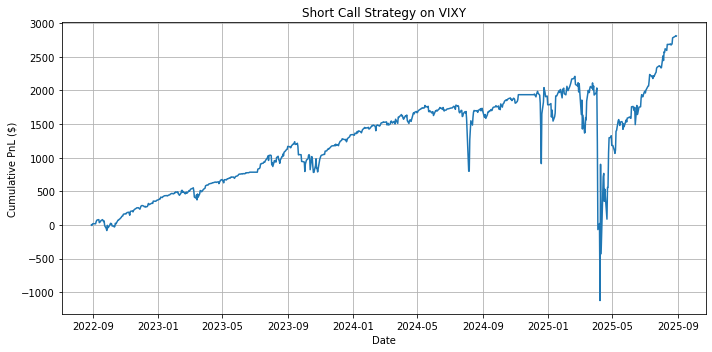

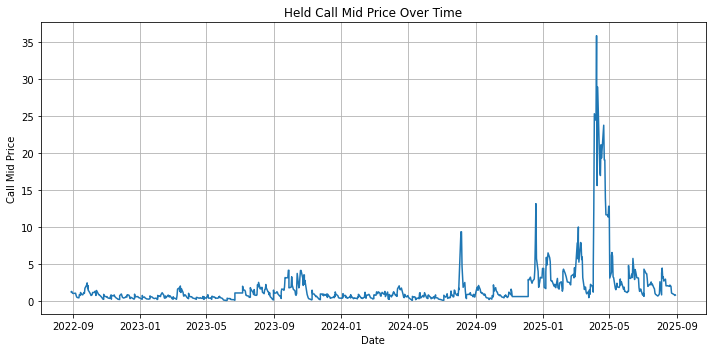

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SHORT CALL STRATEGY ON VIXY OPTIONS
#
# Entry:
#   - choose expiration with DTE closest to TARGET_DTE
#   - choose CALL with delta closest to +0.50
#   - sell 1 call
#
# Exit / roll:
#   - hold exact option ID
#   - roll when remaining DTE <= ROLL_DTE
#   - try same-day re-entry if possible
#
# PnL for a short call:
#   position_value_t = - call_mid_t * 100 * contracts
#   daily_pnl = position_value_t - position_value_{t-1}
# ============================================================

FILE = "b10xheebr3v3h1vn.csv"

TARGET_DTE = 30
MIN_ENTRY_DTE = 12
ROLL_DTE = 15 or 10
CALL_TARGET_DELTA = 0.50

CONTRACTS = 1
MULTIPLIER = 100
COMMISSION_PER_CONTRACT_PER_LEG = 0.00

START_DATE = None   # e.g. "2022-08-29"
END_DATE = None     # e.g. "2025-08-29"

# ------------------------------------------------------------
# Load and clean
# ------------------------------------------------------------
df = pd.read_csv(FILE, low_memory=False)

df["date"] = pd.to_datetime(df["date"])
df["exdate"] = pd.to_datetime(df["exdate"])

if START_DATE is not None:
    df = df[df["date"] >= pd.to_datetime(START_DATE)].copy()
if END_DATE is not None:
    df = df[df["date"] <= pd.to_datetime(END_DATE)].copy()

df = df[df["contract_size"] == 100].copy()
df = df[
    df["best_bid"].notna() &
    df["best_offer"].notna() &
    df["delta"].notna()
].copy()

df["mid"] = (df["best_bid"] + df["best_offer"]) / 2.0
df["dte"] = (df["exdate"] - df["date"]).dt.days

df = df[(df["dte"] > 0) & (df["best_offer"] >= df["best_bid"])].copy()
df = df.sort_values(["date", "exdate", "cp_flag", "strike_price"]).reset_index(drop=True)

# Keep calls only for this strategy
calls_df = df[df["cp_flag"] == "C"].copy()

# quote lookup by optionid
quotes_by_option = {
    oid: grp[["date", "mid"]].drop_duplicates("date").set_index("date").sort_index()
    for oid, grp in calls_df.groupby("optionid")
}

calendar = sorted(calls_df["date"].unique())

# ------------------------------------------------------------
# Entry selection
# ------------------------------------------------------------
def select_short_call(day_df, target_dte=30, min_entry_dte=12, call_target=0.50):
    """
    Choose:
      - expiration with DTE >= min_entry_dte and closest to target_dte
      - call with delta closest to +0.50
    """
    if day_df.empty:
        return None

    exp_table = (
        day_df.groupby("exdate", as_index=False)["dte"]
        .first()
        .sort_values("exdate")
    )

    exp_table = exp_table[exp_table["dte"] >= min_entry_dte].copy()
    if exp_table.empty:
        return None

    exp_table["dte_dist"] = (exp_table["dte"] - target_dte).abs()
    chosen_exdate = exp_table.sort_values(["dte_dist", "dte"]).iloc[0]["exdate"]

    sub = day_df[day_df["exdate"] == chosen_exdate].copy()
    if sub.empty:
        return None

    sub["delta_dist"] = (sub["delta"] - call_target).abs()
    chosen = sub.sort_values(["delta_dist", "strike_price"]).iloc[0]

    return {
        "entry_date": chosen["date"],
        "exdate": chosen["exdate"],
        "entry_dte": int(chosen["dte"]),
        "optionid": int(chosen["optionid"]),
        "strike": chosen["strike_price"] / 1000.0,
        "delta": float(chosen["delta"]),
        "mid": float(chosen["mid"]),
    }

# ------------------------------------------------------------
# Backtest
# ------------------------------------------------------------
daily_rows = []
trades = []

in_position = False
current_trade = None
last_position_value = None
trade_id = 0

def open_trade(entry):
    global in_position, current_trade, last_position_value, trade_id
    trade_id += 1
    in_position = True
    current_trade = {
        "trade_id": trade_id,
        **entry
    }
    # Short call value
    last_position_value = -entry["mid"] * MULTIPLIER * CONTRACTS

for current_date in calendar:
    day_df = calls_df[calls_df["date"] == current_date].copy()

    # --------------------------------------------------------
    # Enter if flat
    # --------------------------------------------------------
    if not in_position:
        entry = select_short_call(
            day_df,
            target_dte=TARGET_DTE,
            min_entry_dte=MIN_ENTRY_DTE,
            call_target=CALL_TARGET_DELTA
        )

        if entry is None:
            daily_rows.append({
                "date": current_date,
                "trade_open": False,
                "trade_id": np.nan,
                "position_value": 0.0,
                "daily_pnl": 0.0,
                "call_px": np.nan,
                "dte": np.nan
            })
            continue

        open_trade(entry)

        entry_cost = COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS
        daily_rows.append({
            "date": current_date,
            "trade_open": True,
            "trade_id": current_trade["trade_id"],
            "optionid": current_trade["optionid"],
            "strike": current_trade["strike"],
            "delta": current_trade["delta"],
            "call_px": current_trade["mid"],
            "position_value": last_position_value,
            "daily_pnl": -entry_cost,
            "dte": (current_trade["exdate"] - current_date).days
        })
        continue

    # --------------------------------------------------------
    # Mark current short call
    # --------------------------------------------------------
    optionid = current_trade["optionid"]
    exdate = current_trade["exdate"]
    remaining_dte = (exdate - current_date).days

    prev_row = daily_rows[-1] if daily_rows else None

    call_px = np.nan
    if optionid in quotes_by_option and current_date in quotes_by_option[optionid].index:
        call_px = float(quotes_by_option[optionid].loc[current_date, "mid"])

    # carry forward if missing
    if np.isnan(call_px) and prev_row is not None:
        call_px = prev_row.get("call_px", np.nan)

    if np.isnan(call_px):
        position_value = last_position_value
        daily_pnl = 0.0
    else:
        position_value = -call_px * MULTIPLIER * CONTRACTS
        daily_pnl = position_value - last_position_value
        last_position_value = position_value

    daily_rows.append({
        "date": current_date,
        "trade_open": True,
        "trade_id": current_trade["trade_id"],
        "optionid": optionid,
        "strike": current_trade["strike"],
        "delta": current_trade["delta"],
        "call_px": call_px,
        "position_value": position_value,
        "daily_pnl": daily_pnl,
        "dte": remaining_dte
    })

    # --------------------------------------------------------
    # Roll
    # --------------------------------------------------------
    if remaining_dte <= ROLL_DTE:
        exit_cost = COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS
        daily_rows[-1]["daily_pnl"] -= exit_cost

        trade_rows = [r for r in daily_rows if r.get("trade_id") == current_trade["trade_id"]]
        trade_pnl = sum(r["daily_pnl"] for r in trade_rows)

        trades.append({
            "trade_id": current_trade["trade_id"],
            "entry_date": current_trade["entry_date"],
            "exit_date": current_date,
            "exdate": current_trade["exdate"],
            "entry_dte": current_trade["entry_dte"],
            "exit_dte": remaining_dte,
            "optionid": current_trade["optionid"],
            "strike": current_trade["strike"],
            "entry_delta": current_trade["delta"],
            "trade_pnl": trade_pnl
        })

        in_position = False
        current_trade = None
        last_position_value = None

        # same-day re-entry
        same_day_entry = select_short_call(
            day_df,
            target_dte=TARGET_DTE,
            min_entry_dte=MIN_ENTRY_DTE,
            call_target=CALL_TARGET_DELTA
        )

        if same_day_entry is not None and same_day_entry["entry_dte"] > ROLL_DTE:
            open_trade(same_day_entry)
            entry_cost = COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS

            daily_rows.append({
                "date": current_date,
                "trade_open": True,
                "trade_id": current_trade["trade_id"],
                "optionid": current_trade["optionid"],
                "strike": current_trade["strike"],
                "delta": current_trade["delta"],
                "call_px": current_trade["mid"],
                "position_value": last_position_value,
                "daily_pnl": -entry_cost,
                "dte": (current_trade["exdate"] - current_date).days
            })

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
daily = pd.DataFrame(daily_rows)
trades_df = pd.DataFrame(trades)

if not daily.empty:
    daily = daily.sort_values(["date", "trade_id"], na_position="last").reset_index(drop=True)
    daily["daily_pnl"] = pd.to_numeric(daily["daily_pnl"], errors="coerce").fillna(0.0)
    daily["cum_pnl"] = daily["daily_pnl"].cumsum()

print("\n===== PERFORMANCE SUMMARY =====")
if not daily.empty:
    print(f"Total PnL ($): {daily['cum_pnl'].iloc[-1]:.2f}")
    print(f"Completed trades: {len(trades_df)}")
    print(f"Average trade PnL ($): {trades_df['trade_pnl'].mean():.2f}" if not trades_df.empty else "Average trade PnL ($): N/A")
    print(f"Trade PnL std($): {trades_df['trade_pnl'].std():.2f}" if not trades_df.empty else "Trade PnL std ($): N/A")
    print(f"Win rate: {(trades_df['trade_pnl'] > 0).mean():.2%}" if not trades_df.empty else "Win rate: N/A")

if not trades_df.empty:
    print("\n===== TRADE SUMMARY =====")
    print(trades_df.to_string(index=False))

# Cumulative PnL
plt.figure(figsize=(10, 5))
plt.plot(daily["date"].to_numpy(), daily["cum_pnl"].to_numpy())
plt.title("Short Call Strategy on VIXY")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig("short_call.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Call price of current held position
held = daily[daily["trade_open"] == True].copy()
if not held.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(held["date"].to_numpy(), held["call_px"].to_numpy())
    plt.title("Held Call Mid Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Call Mid Price")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

daily_short_call = daily.copy()


===== PERFORMANCE SUMMARY =====
Total PnL ($): 748.00
Completed trades: 67
Average trade PnL ($): 11.80
Trade PnL std($): 59.40
Win rate: 56.72%

===== TRADE SUMMARY =====
 trade_id entry_date  exit_date     exdate  entry_dte  exit_dte  short_call_strike  long_call_strike  short_put_strike  long_put_strike     trade_pnl
        1 2022-08-29 2022-09-15 2022-09-30         32        15               19.0              25.0              11.0              8.5  1.250000e+01
        2 2022-09-15 2022-09-29 2022-10-14         29        15               19.0              22.0              13.0             10.0 -3.750000e+01
        3 2022-09-29 2022-10-13 2022-10-28         29        15               23.0              25.0              14.5             10.5 -2.500000e+00
        4 2022-10-13 2022-10-27 2022-11-11         29        15               23.0              25.0              15.0             11.0 -4.000000e+01
        5 2022-10-27 2022-11-10 2022-11-25         29        15              

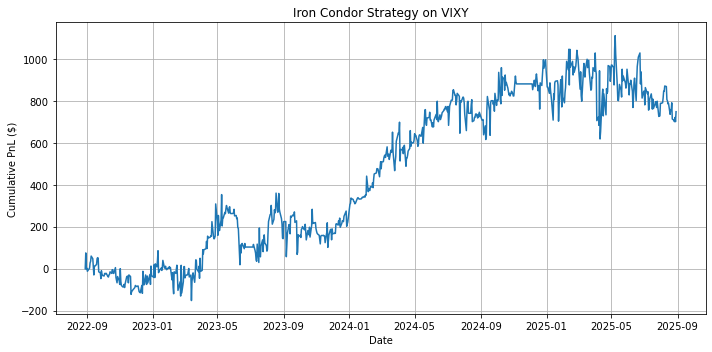

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# IRON CONDOR ON VIXY OPTIONS
#
# Structure (same expiration):
#   Short Call  ~ +0.20 delta
#   Long  Call  ~ +0.10 delta
#   Short Put   ~ -0.20 delta
#   Long  Put   ~ -0.10 delta
#
# Net position value:
#   - short call
#   + long call
#   - short put
#   + long put
#
# Roll when DTE <= ROLL_DTE


FILE = "b10xheebr3v3h1vn.csv"

TARGET_DTE = 30
MIN_ENTRY_DTE = 12
ROLL_DTE = 15 or 10

SHORT_CALL_DELTA = 0.20
LONG_CALL_DELTA  = 0.10
SHORT_PUT_DELTA  = -0.20
LONG_PUT_DELTA   = -0.10

CONTRACTS = 1
MULTIPLIER = 100
COMMISSION_PER_CONTRACT_PER_LEG = 0.00

START_DATE = None   # e.g. "2022-08-29"
END_DATE = None     # e.g. "2025-08-29"


# Load and clean
# ------------------------------------------------------------
df = pd.read_csv(FILE, low_memory=False)

df["date"] = pd.to_datetime(df["date"])
df["exdate"] = pd.to_datetime(df["exdate"])

if START_DATE is not None:
    df = df[df["date"] >= pd.to_datetime(START_DATE)].copy()
if END_DATE is not None:
    df = df[df["date"] <= pd.to_datetime(END_DATE)].copy()

df = df[df["contract_size"] == 100].copy()
df = df[
    df["best_bid"].notna() &
    df["best_offer"].notna() &
    df["delta"].notna()
].copy()

df["mid"] = (df["best_bid"] + df["best_offer"]) / 2.0
df["dte"] = (df["exdate"] - df["date"]).dt.days

df = df[(df["dte"] > 0) & (df["best_offer"] >= df["best_bid"])].copy()
df = df.sort_values(["date", "exdate", "cp_flag", "strike_price"]).reset_index(drop=True)

calendar = sorted(df["date"].unique())

# ------------------------------------------------------------
# Quote lookup
# ------------------------------------------------------------
quotes_by_option = {
    oid: grp[["date", "mid"]].drop_duplicates("date").set_index("date").sort_index()
    for oid, grp in df.groupby("optionid")
}

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def choose_by_delta(sub_df, target_delta, ascending_strike=True):
    x = sub_df.copy()
    x["delta_dist"] = (x["delta"] - target_delta).abs()
    x = x.sort_values(["delta_dist", "strike_price"], ascending=[True, ascending_strike])
    if x.empty:
        return None
    return x.iloc[0]

def select_iron_condor(
    day_df,
    target_dte=30,
    min_entry_dte=12,
    short_call_delta=0.20,
    long_call_delta=0.10,
    short_put_delta=-0.20,
    long_put_delta=-0.10
):
    """
    Choose one expiration, then 4 legs:
      short call ~ +0.20
      long call  ~ +0.10   with strike >= short call strike
      short put  ~ -0.20
      long put   ~ -0.10   with strike <= short put strike
    """
    if day_df.empty:
        return None

    exp_counts = day_df.groupby(["exdate", "cp_flag"]).size().unstack(fill_value=0)
    valid_exdates = exp_counts[(exp_counts.get("C", 0) > 0) & (exp_counts.get("P", 0) > 0)].index
    if len(valid_exdates) == 0:
        return None

    exp_table = (
        day_df[day_df["exdate"].isin(valid_exdates)]
        .groupby("exdate", as_index=False)["dte"]
        .first()
    )

    exp_table = exp_table[exp_table["dte"] >= min_entry_dte].copy()
    if exp_table.empty:
        return None

    exp_table["dte_dist"] = (exp_table["dte"] - target_dte).abs()
    chosen_exdate = exp_table.sort_values(["dte_dist", "dte"]).iloc[0]["exdate"]

    sub = day_df[day_df["exdate"] == chosen_exdate].copy()
    calls = sub[sub["cp_flag"] == "C"].copy()
    puts  = sub[sub["cp_flag"] == "P"].copy()

    if calls.empty or puts.empty:
        return None

    # Short call near +0.20
    short_call = choose_by_delta(calls, short_call_delta, ascending_strike=True)
    if short_call is None:
        return None

    # Long call near +0.10, but strike must be >= short call strike
    long_call_candidates = calls[calls["strike_price"] >= short_call["strike_price"]].copy()
    if long_call_candidates.empty:
        return None
    long_call = choose_by_delta(long_call_candidates, long_call_delta, ascending_strike=True)
    if long_call is None:
        return None

    # Ensure long call strike is strictly above if possible
    if long_call["strike_price"] == short_call["strike_price"]:
        tmp = long_call_candidates[long_call_candidates["strike_price"] > short_call["strike_price"]].copy()
        if not tmp.empty:
            long_call = choose_by_delta(tmp, long_call_delta, ascending_strike=True)

    # Short put near -0.20
    short_put = choose_by_delta(puts, short_put_delta, ascending_strike=False)
    if short_put is None:
        return None

    # Long put near -0.10, but strike must be <= short put strike
    long_put_candidates = puts[puts["strike_price"] <= short_put["strike_price"]].copy()
    if long_put_candidates.empty:
        return None
    long_put = choose_by_delta(long_put_candidates, long_put_delta, ascending_strike=False)
    if long_put is None:
        return None

    # Ensure long put strike is strictly below if possible
    if long_put["strike_price"] == short_put["strike_price"]:
        tmp = long_put_candidates[long_put_candidates["strike_price"] < short_put["strike_price"]].copy()
        if not tmp.empty:
            long_put = choose_by_delta(tmp, long_put_delta, ascending_strike=False)

    return {
        "entry_date": short_call["date"],
        "exdate": short_call["exdate"],
        "entry_dte": int(short_call["dte"]),

        "short_call_id": int(short_call["optionid"]),
        "long_call_id": int(long_call["optionid"]),
        "short_put_id": int(short_put["optionid"]),
        "long_put_id": int(long_put["optionid"]),

        "short_call_strike": short_call["strike_price"] / 1000.0,
        "long_call_strike": long_call["strike_price"] / 1000.0,
        "short_put_strike": short_put["strike_price"] / 1000.0,
        "long_put_strike": long_put["strike_price"] / 1000.0,

        "short_call_delta": float(short_call["delta"]),
        "long_call_delta": float(long_call["delta"]),
        "short_put_delta": float(short_put["delta"]),
        "long_put_delta": float(long_put["delta"]),

        "short_call_mid": float(short_call["mid"]),
        "long_call_mid": float(long_call["mid"]),
        "short_put_mid": float(short_put["mid"]),
        "long_put_mid": float(long_put["mid"]),
    }

def get_mid(optionid, current_date):
    if optionid in quotes_by_option and current_date in quotes_by_option[optionid].index:
        return float(quotes_by_option[optionid].loc[current_date, "mid"])
    return np.nan

def condor_value(sc, lc, sp, lp):
    # short call + long call + short put + long put
    return (-sc + lc - sp + lp) * MULTIPLIER * CONTRACTS

# ------------------------------------------------------------
# Backtest
# ------------------------------------------------------------
daily_rows = []
trades = []

in_position = False
current_trade = None
last_position_value = None
trade_id = 0

def open_trade(entry):
    global in_position, current_trade, last_position_value, trade_id
    trade_id += 1
    in_position = True
    current_trade = {"trade_id": trade_id, **entry}
    last_position_value = condor_value(
        entry["short_call_mid"],
        entry["long_call_mid"],
        entry["short_put_mid"],
        entry["long_put_mid"]
    )

for current_date in calendar:
    day_df = df[df["date"] == current_date].copy()

    # Enter if flat
    if not in_position:
        entry = select_iron_condor(
            day_df,
            target_dte=TARGET_DTE,
            min_entry_dte=MIN_ENTRY_DTE,
            short_call_delta=SHORT_CALL_DELTA,
            long_call_delta=LONG_CALL_DELTA,
            short_put_delta=SHORT_PUT_DELTA,
            long_put_delta=LONG_PUT_DELTA
        )

        if entry is None:
            daily_rows.append({
                "date": current_date,
                "trade_open": False,
                "trade_id": np.nan,
                "position_value": 0.0,
                "daily_pnl": 0.0,
                "dte": np.nan
            })
            continue

        open_trade(entry)
        entry_cost = 4 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS

        daily_rows.append({
            "date": current_date,
            "trade_open": True,
            "trade_id": current_trade["trade_id"],
            "position_value": last_position_value,
            "daily_pnl": -entry_cost,
            "dte": (current_trade["exdate"] - current_date).days,
            "sc_px": current_trade["short_call_mid"],
            "lc_px": current_trade["long_call_mid"],
            "sp_px": current_trade["short_put_mid"],
            "lp_px": current_trade["long_put_mid"],
        })
        continue

    # Mark existing trade
    exdate = current_trade["exdate"]
    remaining_dte = (exdate - current_date).days
    prev_row = daily_rows[-1] if daily_rows else None

    sc_px = get_mid(current_trade["short_call_id"], current_date)
    lc_px = get_mid(current_trade["long_call_id"], current_date)
    sp_px = get_mid(current_trade["short_put_id"], current_date)
    lp_px = get_mid(current_trade["long_put_id"], current_date)

    # carry forward missing quotes
    if np.isnan(sc_px) and prev_row is not None:
        sc_px = prev_row.get("sc_px", np.nan)
    if np.isnan(lc_px) and prev_row is not None:
        lc_px = prev_row.get("lc_px", np.nan)
    if np.isnan(sp_px) and prev_row is not None:
        sp_px = prev_row.get("sp_px", np.nan)
    if np.isnan(lp_px) and prev_row is not None:
        lp_px = prev_row.get("lp_px", np.nan)

    if np.isnan(sc_px) or np.isnan(lc_px) or np.isnan(sp_px) or np.isnan(lp_px):
        position_value = last_position_value
        daily_pnl = 0.0
    else:
        position_value = condor_value(sc_px, lc_px, sp_px, lp_px)
        daily_pnl = position_value - last_position_value
        last_position_value = position_value

    daily_rows.append({
        "date": current_date,
        "trade_open": True,
        "trade_id": current_trade["trade_id"],
        "position_value": position_value,
        "daily_pnl": daily_pnl,
        "dte": remaining_dte,
        "sc_px": sc_px,
        "lc_px": lc_px,
        "sp_px": sp_px,
        "lp_px": lp_px,
    })

    # Roll
    if remaining_dte <= ROLL_DTE:
        exit_cost = 4 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS
        daily_rows[-1]["daily_pnl"] -= exit_cost

        trade_rows = [r for r in daily_rows if r.get("trade_id") == current_trade["trade_id"]]
        trade_pnl = sum(r["daily_pnl"] for r in trade_rows)

        trades.append({
            "trade_id": current_trade["trade_id"],
            "entry_date": current_trade["entry_date"],
            "exit_date": current_date,
            "exdate": current_trade["exdate"],
            "entry_dte": current_trade["entry_dte"],
            "exit_dte": remaining_dte,

            "short_call_strike": current_trade["short_call_strike"],
            "long_call_strike": current_trade["long_call_strike"],
            "short_put_strike": current_trade["short_put_strike"],
            "long_put_strike": current_trade["long_put_strike"],

            "trade_pnl": trade_pnl
        })

        in_position = False
        current_trade = None
        last_position_value = None

        # same-day re-entry
        same_day_entry = select_iron_condor(
            day_df,
            target_dte=TARGET_DTE,
            min_entry_dte=MIN_ENTRY_DTE,
            short_call_delta=SHORT_CALL_DELTA,
            long_call_delta=LONG_CALL_DELTA,
            short_put_delta=SHORT_PUT_DELTA,
            long_put_delta=LONG_PUT_DELTA
        )

        if same_day_entry is not None and same_day_entry["entry_dte"] > ROLL_DTE:
            open_trade(same_day_entry)
            entry_cost = 4 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS

            daily_rows.append({
                "date": current_date,
                "trade_open": True,
                "trade_id": current_trade["trade_id"],
                "position_value": last_position_value,
                "daily_pnl": -entry_cost,
                "dte": (current_trade["exdate"] - current_date).days,
                "sc_px": current_trade["short_call_mid"],
                "lc_px": current_trade["long_call_mid"],
                "sp_px": current_trade["short_put_mid"],
                "lp_px": current_trade["long_put_mid"],
            })

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
daily = pd.DataFrame(daily_rows)
trades_df = pd.DataFrame(trades)

if not daily.empty:
    daily = daily.sort_values(["date", "trade_id"], na_position="last").reset_index(drop=True)
    daily["daily_pnl"] = pd.to_numeric(daily["daily_pnl"], errors="coerce").fillna(0.0)
    daily["cum_pnl"] = daily["daily_pnl"].cumsum()

print("\n===== PERFORMANCE SUMMARY =====")
if not daily.empty:
    print(f"Total PnL ($): {daily['cum_pnl'].iloc[-1]:.2f}")
    print(f"Completed trades: {len(trades_df)}")
    print(f"Average trade PnL ($): {trades_df['trade_pnl'].mean():.2f}" if not trades_df.empty else "Average trade PnL ($): N/A")
    print(f"Trade PnL std($): {trades_df['trade_pnl'].std():.2f}" if not trades_df.empty else "Trade PnL std ($): N/A")
    print(f"Win rate: {(trades_df['trade_pnl'] > 0).mean():.2%}" if not trades_df.empty else "Win rate: N/A")

if not trades_df.empty:
    print("\n===== TRADE SUMMARY =====")
    print(trades_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(daily["date"].to_numpy(), daily["cum_pnl"].to_numpy())
plt.title("Iron Condor Strategy on VIXY")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig("Iron_Condor.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

daily_condor = daily.copy()


===== PERFORMANCE SUMMARY =====

===== PERFORMANCE SUMMARY =====
Total PnL ($): 2059.00
Number of completed trades: 154
Average trade PnL ($): 13.32
Trade PnL std ($): 85.03
Win rate: 37.66%

===== TRADE SUMMARY =====
 trade_id entry_date  exit_date     exdate  entry_dte  exit_dte  strike  call_optionid  put_optionid  entry_call_delta  entry_put_delta     trade_pnl                  exit_note
        1 2022-08-29 2022-09-20 2022-09-30         32        10    15.0      148915193     148915214          0.497931        -0.505672  1.375000e+02                  roll exit
        2 2022-09-20 2022-10-06 2022-10-21         31        15    15.0      148521056     148521082          0.520145        -0.479674  7.250000e+01 forced exit: missing quote
        3 2022-10-06 2022-10-25 2022-11-04         29        10    16.5      149896738     149896759          0.510324        -0.485341  1.300000e+02                  roll exit
        4 2022-10-25 2022-11-10 2022-11-25         31        15    16.0  

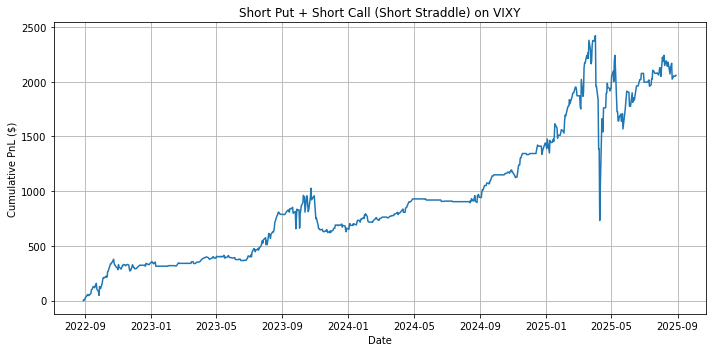

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SHORT PUT + SHORT CALL (SHORT STRADDLE) ON VIXY
#
# Entry:
#   - choose expiration with DTE closest to TARGET_DTE
#   - choose one SAME-STRIKE call/put pair
#   - call delta closest to +0.50
#   - put delta closest to -0.50
#   - sell 1 call and sell 1 put
#
# Exit / roll:
#   - hold exact option IDs
#   - roll when remaining DTE <= ROLL_DTE
#   - if quotes disappear, FORCE EXIT instead of freezing PnL
#   - try same-day re-entry if possible
#
# Position value:
#   short call + short put
#   V_t = -(call_mid_t + put_mid_t) * 100 * contracts
# ============================================================

FILE = "b10xheebr3v3h1vn.csv"

TARGET_DTE = 30
MIN_ENTRY_DTE = 20
ROLL_DTE = 10

CALL_TARGET_DELTA = 0.50
PUT_TARGET_DELTA = -0.50

CONTRACTS = 1
MULTIPLIER = 100
COMMISSION_PER_CONTRACT_PER_LEG = 0.00

START_DATE = "2022-08-29"
END_DATE = "2025-08-29"

MAX_SPREAD_PCT = 0.50
MIN_MID = 0.05

# ------------------------------------------------------------
# Load and clean data
# ------------------------------------------------------------
df = pd.read_csv(FILE, low_memory=False)

df["date"] = pd.to_datetime(df["date"])
df["exdate"] = pd.to_datetime(df["exdate"])

df = df[
    (df["date"] >= pd.to_datetime(START_DATE)) &
    (df["date"] <= pd.to_datetime(END_DATE))
].copy()

df = df[df["contract_size"] == 100].copy()
df = df[
    df["best_bid"].notna() &
    df["best_offer"].notna() &
    df["delta"].notna()
].copy()

df = df[df["best_offer"] >= df["best_bid"]].copy()

df["mid"] = (df["best_bid"] + df["best_offer"]) / 2.0
df["spread_pct"] = np.where(
    df["mid"] > 0,
    (df["best_offer"] - df["best_bid"]) / df["mid"],
    np.nan
)
df["strike"] = df["strike_price"] / 1000.0
df["dte_days"] = (df["exdate"] - df["date"]).dt.days

df = df[
    (df["dte_days"] > 0) &
    (df["mid"] >= MIN_MID) &
    (df["spread_pct"] <= MAX_SPREAD_PCT)
].copy()

df = df.sort_values(["date", "exdate", "cp_flag", "strike"]).reset_index(drop=True)

# ------------------------------------------------------------
# Quote lookup by optionid
# ------------------------------------------------------------
quotes_by_option = {
    oid: grp[["date", "mid"]].drop_duplicates("date").set_index("date").sort_index()
    for oid, grp in df.groupby("optionid")
}

calendar = sorted(df["date"].unique())

# ------------------------------------------------------------
# Select one same-strike short straddle pair
# ------------------------------------------------------------
def select_short_straddle(day_df, target_dte=30, min_entry_dte=20):
    """
    For one date:
      1) choose expiry with DTE >= min_entry_dte closest to target_dte
      2) inside that expiry, require exact same-strike call/put pairs
      3) choose pair minimizing:
           |call_delta - 0.50| + |put_delta + 0.50|
    """
    if day_df.empty:
        return None

    exp_counts = day_df.groupby(["exdate", "cp_flag"]).size().unstack(fill_value=0)
    valid_exdates = exp_counts[(exp_counts.get("C", 0) > 0) & (exp_counts.get("P", 0) > 0)].index

    if len(valid_exdates) == 0:
        return None

    exp_table = (
        day_df[day_df["exdate"].isin(valid_exdates)]
        .groupby("exdate", as_index=False)["dte_days"]
        .first()
    )

    exp_table = exp_table[exp_table["dte_days"] >= min_entry_dte].copy()
    if exp_table.empty:
        return None

    exp_table["dte_dist"] = (exp_table["dte_days"] - target_dte).abs()
    chosen_exdate = exp_table.sort_values(["dte_dist", "dte_days"]).iloc[0]["exdate"]

    sub = day_df[day_df["exdate"] == chosen_exdate].copy()
    calls = sub[sub["cp_flag"] == "C"].copy()
    puts = sub[sub["cp_flag"] == "P"].copy()

    if calls.empty or puts.empty:
        return None

    call_map = {k: g.iloc[0] for k, g in calls.groupby("strike")}
    put_map = {k: g.iloc[0] for k, g in puts.groupby("strike")}
    common_strikes = sorted(set(call_map.keys()) & set(put_map.keys()))

    if not common_strikes:
        return None

    candidates = []
    for strike in common_strikes:
        c = call_map[strike]
        p = put_map[strike]
        score = abs(c["delta"] - CALL_TARGET_DELTA) + abs(p["delta"] - PUT_TARGET_DELTA)
        candidates.append((score, strike, c, p))

    if not candidates:
        return None

    candidates.sort(key=lambda x: (x[0], x[1]))
    _, strike, chosen_call, chosen_put = candidates[0]

    return {
        "entry_date": chosen_call["date"],
        "exdate": chosen_call["exdate"],
        "entry_dte": int(chosen_call["dte_days"]),
        "strike": float(strike),
        "call_optionid": int(chosen_call["optionid"]),
        "put_optionid": int(chosen_put["optionid"]),
        "call_delta": float(chosen_call["delta"]),
        "put_delta": float(chosen_put["delta"]),
        "call_mid": float(chosen_call["mid"]),
        "put_mid": float(chosen_put["mid"]),
    }

# ------------------------------------------------------------
# Backtest
# ------------------------------------------------------------
daily_rows = []
trades = []

in_position = False
current_trade = None
last_position_value = None
trade_id = 0

def open_trade(entry):
    global in_position, current_trade, last_position_value, trade_id
    trade_id += 1
    in_position = True
    current_trade = {"trade_id": trade_id, **entry}
    last_position_value = -(entry["call_mid"] + entry["put_mid"]) * MULTIPLIER * CONTRACTS

def close_trade(exit_date, exit_dte, note="normal exit"):
    global in_position, current_trade, last_position_value

    trade_rows = [r for r in daily_rows if r.get("trade_id") == current_trade["trade_id"]]
    trade_pnl = sum(r["daily_pnl"] for r in trade_rows) if trade_rows else np.nan

    trades.append({
        "trade_id": current_trade["trade_id"],
        "entry_date": current_trade["entry_date"],
        "exit_date": exit_date,
        "exdate": current_trade["exdate"],
        "entry_dte": current_trade["entry_dte"],
        "exit_dte": exit_dte,
        "strike": current_trade["strike"],
        "call_optionid": current_trade["call_optionid"],
        "put_optionid": current_trade["put_optionid"],
        "entry_call_delta": current_trade["call_delta"],
        "entry_put_delta": current_trade["put_delta"],
        "trade_pnl": trade_pnl,
        "exit_note": note
    })

    in_position = False
    current_trade = None
    last_position_value = None

for current_date in calendar:
    day_df = df[df["date"] == current_date].copy()

    # --------------------------------------------------------
    # Enter if flat
    # --------------------------------------------------------
    if not in_position:
        entry = select_short_straddle(
            day_df,
            target_dte=TARGET_DTE,
            min_entry_dte=MIN_ENTRY_DTE
        )

        if entry is None:
            daily_rows.append({
                "date": current_date,
                "trade_open": False,
                "trade_id": np.nan,
                "call_optionid": np.nan,
                "put_optionid": np.nan,
                "call_px": np.nan,
                "put_px": np.nan,
                "strike": np.nan,
                "position_value": np.nan,
                "daily_pnl": 0.0,
                "dte": np.nan
            })
            continue

        open_trade(entry)

        entry_cost = 2 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS
        daily_rows.append({
            "date": current_date,
            "trade_open": True,
            "trade_id": current_trade["trade_id"],
            "call_optionid": current_trade["call_optionid"],
            "put_optionid": current_trade["put_optionid"],
            "call_px": current_trade["call_mid"],
            "put_px": current_trade["put_mid"],
            "strike": current_trade["strike"],
            "position_value": last_position_value,
            "daily_pnl": -entry_cost,
            "dte": (current_trade["exdate"] - current_date).days
        })
        continue

    # --------------------------------------------------------
    # Mark current trade
    # --------------------------------------------------------
    call_oid = current_trade["call_optionid"]
    put_oid = current_trade["put_optionid"]
    exdate = current_trade["exdate"]
    remaining_dte = (exdate - current_date).days

    call_px = np.nan
    put_px = np.nan

    if call_oid in quotes_by_option and current_date in quotes_by_option[call_oid].index:
        call_px = float(quotes_by_option[call_oid].loc[current_date, "mid"])
    if put_oid in quotes_by_option and current_date in quotes_by_option[put_oid].index:
        put_px = float(quotes_by_option[put_oid].loc[current_date, "mid"])

    # --------------------------------------------------------
    # If quotes disappear, FORCE EXIT instead of freezing PnL
    # --------------------------------------------------------
    if np.isnan(call_px) or np.isnan(put_px):
        close_trade(current_date, remaining_dte, note="forced exit: missing quote")

        # Try same-day re-entry
        same_day_entry = select_short_straddle(
            day_df,
            target_dte=TARGET_DTE,
            min_entry_dte=MIN_ENTRY_DTE
        )

        if same_day_entry is not None and same_day_entry["entry_dte"] > ROLL_DTE:
            open_trade(same_day_entry)
            entry_cost = 2 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS

            daily_rows.append({
                "date": current_date,
                "trade_open": True,
                "trade_id": current_trade["trade_id"],
                "call_optionid": current_trade["call_optionid"],
                "put_optionid": current_trade["put_optionid"],
                "call_px": current_trade["call_mid"],
                "put_px": current_trade["put_mid"],
                "strike": current_trade["strike"],
                "position_value": last_position_value,
                "daily_pnl": -entry_cost,
                "dte": (current_trade["exdate"] - current_date).days
            })
        else:
            daily_rows.append({
                "date": current_date,
                "trade_open": False,
                "trade_id": np.nan,
                "call_optionid": np.nan,
                "put_optionid": np.nan,
                "call_px": np.nan,
                "put_px": np.nan,
                "strike": np.nan,
                "position_value": np.nan,
                "daily_pnl": 0.0,
                "dte": np.nan
            })

        continue

    # Valid quote day
    position_value = -(call_px + put_px) * MULTIPLIER * CONTRACTS
    daily_pnl = position_value - last_position_value
    last_position_value = position_value

    daily_rows.append({
        "date": current_date,
        "trade_open": True,
        "trade_id": current_trade["trade_id"],
        "call_optionid": call_oid,
        "put_optionid": put_oid,
        "call_px": call_px,
        "put_px": put_px,
        "strike": current_trade["strike"],
        "position_value": position_value,
        "daily_pnl": daily_pnl,
        "dte": remaining_dte
    })

    # --------------------------------------------------------
    # Roll
    # --------------------------------------------------------
    if remaining_dte <= ROLL_DTE:
        exit_cost = 2 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS
        daily_rows[-1]["daily_pnl"] -= exit_cost

        close_trade(current_date, remaining_dte, note="roll exit")

        # Try same-day re-entry
        same_day_entry = select_short_straddle(
            day_df,
            target_dte=TARGET_DTE,
            min_entry_dte=MIN_ENTRY_DTE
        )

        if same_day_entry is not None and same_day_entry["entry_dte"] > ROLL_DTE:
            open_trade(same_day_entry)
            entry_cost = 2 * COMMISSION_PER_CONTRACT_PER_LEG * CONTRACTS

            daily_rows.append({
                "date": current_date,
                "trade_open": True,
                "trade_id": current_trade["trade_id"],
                "call_optionid": current_trade["call_optionid"],
                "put_optionid": current_trade["put_optionid"],
                "call_px": current_trade["call_mid"],
                "put_px": current_trade["put_mid"],
                "strike": current_trade["strike"],
                "position_value": last_position_value,
                "daily_pnl": -entry_cost,
                "dte": (current_trade["exdate"] - current_date).days
            })

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
daily = pd.DataFrame(daily_rows)
trades_df = pd.DataFrame(trades)

if not daily.empty:
    daily = daily.sort_values(["date", "trade_id"], na_position="last").reset_index(drop=True)
    daily["daily_pnl"] = pd.to_numeric(daily["daily_pnl"], errors="coerce").fillna(0.0)
    daily["cum_pnl"] = daily["daily_pnl"].cumsum()

print("\n===== PERFORMANCE SUMMARY =====")
if not daily.empty:
    print("\n===== PERFORMANCE SUMMARY =====")
    print(f"Total PnL ($): {daily['cum_pnl'].iloc[-1]:.2f}")
    print(f"Number of completed trades: {len(trades_df)}")

    if not trades_df.empty:
        print(f"Average trade PnL ($): {trades_df['trade_pnl'].mean():.2f}")
        print(f"Trade PnL std ($): {trades_df['trade_pnl'].std():.2f}")
        print(f"Win rate: {(trades_df['trade_pnl'] > 0).mean():.2%}")
    else:
        print("Average trade PnL ($): N/A")
        print("Trade PnL std ($): N/A")
        print("Win rate: N/A")

if not trades_df.empty:
    print("\n===== TRADE SUMMARY =====")
    print(trades_df.to_string(index=False))

# ------------------------------------------------------------
# Plot cumulative PnL
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(daily["date"].to_numpy(), daily["cum_pnl"].to_numpy())
plt.title("Short Put + Short Call (Short Straddle) on VIXY")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig("short_put_short_call.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

short_put_short_call = daily.copy()

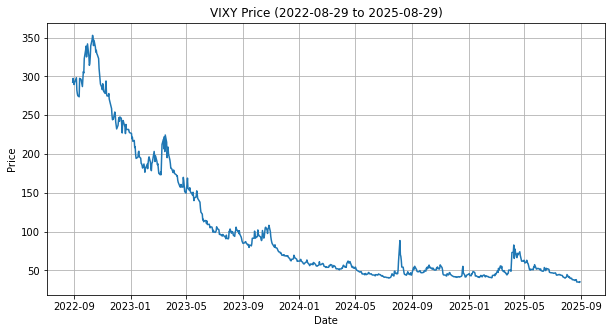

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your Yahoo file
vixy = pd.read_csv("HistoricalData_1774985169796.csv")

# Convert date
vixy["Date"] = pd.to_datetime(vixy["Date"])

# Filter the exact range
start = pd.to_datetime("2022-08-29")
end   = pd.to_datetime("2025-08-29")

vixy_filtered = vixy[
    (vixy["Date"] >= start) &
    (vixy["Date"] <= end)
].copy()

# Sort (important for plotting)
vixy_filtered = vixy_filtered.sort_values("Date")

# Plot
plt.figure(figsize=(10,5))
plt.plot(
    vixy_filtered["Date"].to_numpy(),
    vixy_filtered["Close/Last"].to_numpy()
)
plt.title("VIXY Price (2022-08-29 to 2025-08-29)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

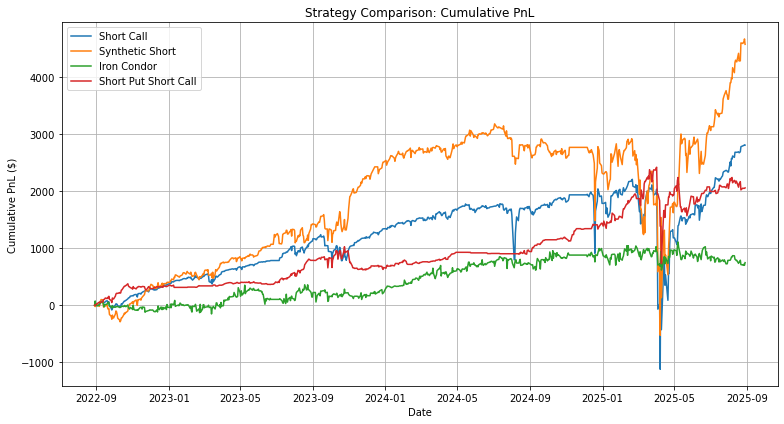

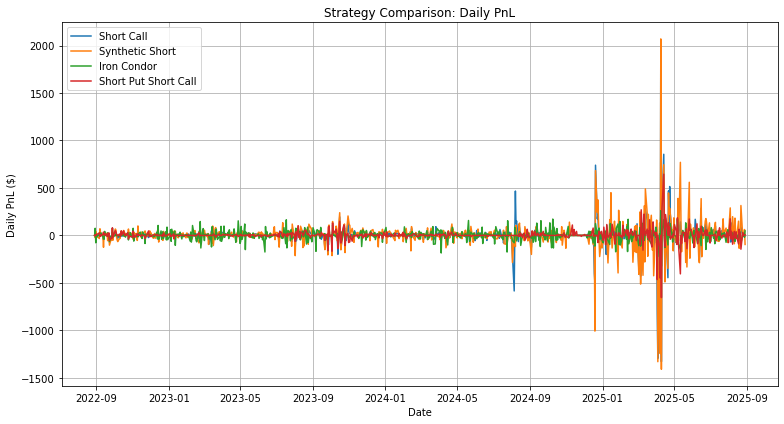

               Strategy  Total PnL  Avg Daily PnL  Daily PnL Std
0            Short Call     2809.5       3.736037     141.682203
1       Synthetic Short     4577.5       6.087101     159.696640
2           Iron Condor      748.0       0.994681      54.261897
3  Short Put Short Call     2059.0       2.738032      59.235289


In [ ]:





import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helper: standardize each strategy dataframe
# ------------------------------------------------------------
def prep_strategy(df, date_col="date", pnl_col="daily_pnl", name="strategy"):
    x = df.copy()
    x[date_col] = pd.to_datetime(x[date_col])
    x = x.sort_values(date_col).copy()

    # aggregate in case there are multiple rows per date
    x = x.groupby(date_col, as_index=False)[pnl_col].sum()

    x = x.rename(columns={
        date_col: "date",
        pnl_col: f"{name}_daily_pnl"
    })

    x[f"{name}_cum_pnl"] = x[f"{name}_daily_pnl"].cumsum()
    return x

# ------------------------------------------------------------
# Prepare each strategy
# ------------------------------------------------------------
sc = prep_strategy(daily_short_call, name="short_call")
ss = prep_strategy(daily_synth, name="synthetic_short")
ic = prep_strategy(daily_condor, name="iron_condor")
spsc = prep_strategy(short_put_short_call, name="short_put_short_call")

# ------------------------------------------------------------
# Merge by date
# ------------------------------------------------------------
compare = sc.merge(ss, on="date", how="outer").merge(ic, on="date", how="outer").merge(spsc, on="date", how="outer")
compare = compare.sort_values("date").fillna(0)

# recompute cumulative PnL after merge/fill
compare["short_call_cum_pnl"] = compare["short_call_daily_pnl"].cumsum()
compare["synthetic_short_cum_pnl"] = compare["synthetic_short_daily_pnl"].cumsum()
compare["iron_condor_cum_pnl"] = compare["iron_condor_daily_pnl"].cumsum()
compare["short_put_short_call_cum_pnl"] = compare["short_put_short_call_daily_pnl"].cumsum()

# ------------------------------------------------------------
# Plot cumulative PnL
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(compare["date"].to_numpy(), compare["short_call_cum_pnl"].to_numpy(), label="Short Call")
plt.plot(compare["date"].to_numpy(), compare["synthetic_short_cum_pnl"].to_numpy(), label="Synthetic Short")
plt.plot(compare["date"].to_numpy(), compare["iron_condor_cum_pnl"].to_numpy(), label="Iron Condor")
plt.plot(compare["date"].to_numpy(), compare["short_put_short_call_cum_pnl"].to_numpy(), label="Short Put Short Call")
plt.title("Strategy Comparison: Cumulative PnL")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Strategy Comparison: Cumulative PnL.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ------------------------------------------------------------
# Plot daily PnL
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(compare["date"].to_numpy(), compare["short_call_daily_pnl"].to_numpy(), label="Short Call")
plt.plot(compare["date"].to_numpy(), compare["synthetic_short_daily_pnl"].to_numpy(), label="Synthetic Short")
plt.plot(compare["date"].to_numpy(), compare["iron_condor_daily_pnl"].to_numpy(), label="Iron Condor")
plt.plot(compare["date"].to_numpy(), compare["short_put_short_call_daily_pnl"].to_numpy(), label="Short Put Short Call")

plt.title("Strategy Comparison: Daily PnL")
plt.xlabel("Date")
plt.ylabel("Daily PnL ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary stats
# ------------------------------------------------------------
summary = pd.DataFrame({
    "Strategy": ["Short Call", "Synthetic Short", "Iron Condor", "Short Put Short Call"],
    "Total PnL": [
        compare["short_call_cum_pnl"].iloc[-1],
        compare["synthetic_short_cum_pnl"].iloc[-1],
        compare["iron_condor_cum_pnl"].iloc[-1],
        compare["short_put_short_call_cum_pnl"].iloc[-1],
    ],
    "Avg Daily PnL": [
        compare["short_call_daily_pnl"].mean(),
        compare["synthetic_short_daily_pnl"].mean(),
        compare["iron_condor_daily_pnl"].mean(),
        compare["short_put_short_call_daily_pnl"].mean(),
    ],
    "Daily PnL Std": [
        compare["short_call_daily_pnl"].std(),
        compare["synthetic_short_daily_pnl"].std(),
        compare["iron_condor_daily_pnl"].std(),
        compare["short_put_short_call_daily_pnl"].std(),
    ],
})

print(summary)

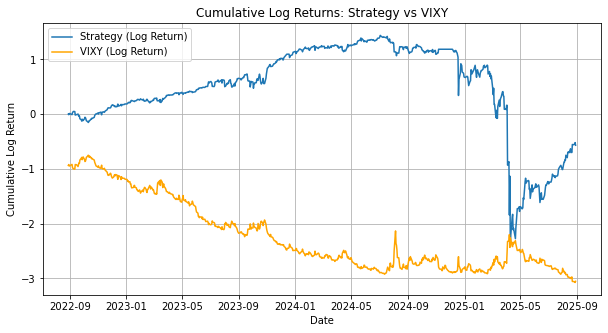

In [ ]:
import numpy as np

vixy = vixy.sort_values("Date").copy()

# log return
vixy["vixy_log_ret"] = np.log(vixy["Close/Last"] / vixy["Close/Last"].shift(1))

# cumulative log return
vixy["vixy_cum_log"] = vixy["vixy_log_ret"].cumsum()

# approximate notional (important!)
NOTIONAL = 2000  # adjust if needed

daily = daily_synth.sort_values("date").copy()

# convert PnL to return
daily["strategy_ret"] = daily["daily_pnl"] / NOTIONAL

# log return
daily["strategy_log_ret"] = np.log(1 + daily["strategy_ret"])

# cumulative log return
daily["strategy_cum_log"] = daily["strategy_log_ret"].cumsum()

merged = pd.merge(
    daily[["date", "strategy_cum_log"]],
    vixy[["Date", "vixy_cum_log"]],
    left_on="date",
    right_on="Date",
    how="inner"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    merged["date"].to_numpy(),
    merged["strategy_cum_log"].to_numpy(),
    label="Strategy (Log Return)"
)

plt.plot(
    merged["date"].to_numpy(),
    merged["vixy_cum_log"].to_numpy(),
    label="VIXY (Log Return)",
    color="orange"
)

plt.title("Cumulative Log Returns: Strategy vs VIXY")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

NOTIONAL = 2000  # adjust if needed

def prep_log(df, name):
    x = df.copy()
    x["date"] = pd.to_datetime(x["date"])
    x = x.sort_values("date")

    # aggregate in case multiple rows per date
    x = x.groupby("date", as_index=False)["daily_pnl"].sum()

    # convert to simple return
    x[f"{name}_ret"] = x["daily_pnl"] / NOTIONAL

    # convert to log return
    x[f"{name}_log_ret"] = np.log(1 + x[f"{name}_ret"])

    # cumulative log return
    x[f"{name}_cum_log"] = x[f"{name}_log_ret"].cumsum()

    return x[["date", f"{name}_cum_log"]]

In [ ]:
sc = prep_log(daily_short_call, "short_call")
ss = prep_log(daily_synth, "synthetic")
ic = prep_log(daily_condor, "condor")

In [ ]:
compare = sc.merge(ss, on="date", how="outer") \
            .merge(ic, on="date", how="outer")

compare = compare.sort_values("date").fillna(0)

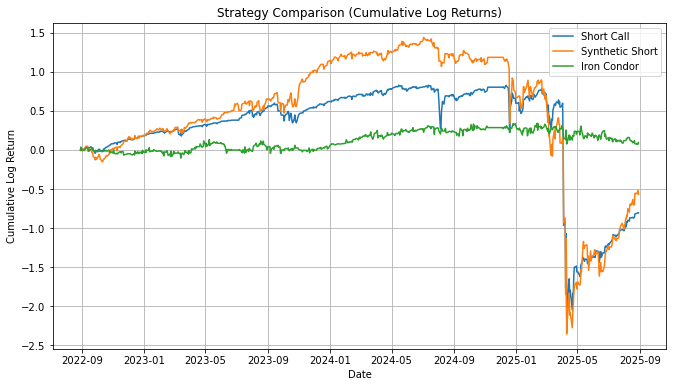

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11,6))

plt.plot(compare["date"].to_numpy(), compare["short_call_cum_log"].to_numpy(), label="Short Call")
plt.plot(compare["date"].to_numpy(), compare["synthetic_cum_log"].to_numpy(), label="Synthetic Short")
plt.plot(compare["date"].to_numpy(), compare["condor_cum_log"].to_numpy(), label="Iron Condor")

plt.title("Strategy Comparison (Cumulative Log Returns)")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True)
plt.show()

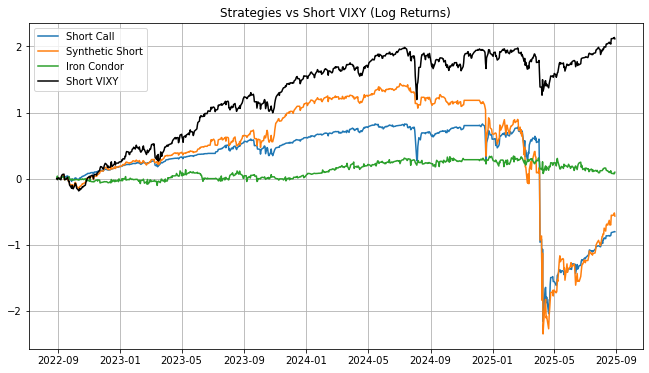

In [ ]:
# VIXY log returns
vixy["vixy_log_ret"] = np.log(vixy["Close/Last"] / vixy["Close/Last"].shift(1))
vixy["vixy_log_ret"] = vixy["vixy_log_ret"].fillna(0)

vixy["vixy_cum_log"] = vixy["vixy_log_ret"].cumsum()

# merge
compare2 = pd.merge(
    compare,
    vixy[["Date", "vixy_cum_log"]],
    left_on="date",
    right_on="Date",
    how="inner"
)

compare2 = compare2.sort_values("date").reset_index(drop=True)

compare2["vixy_cum_log"] = (
    compare2["vixy_cum_log"] - compare2["vixy_cum_log"].iloc[0]
)

# plot
plt.figure(figsize=(11,6))

plt.plot(compare2["date"].to_numpy(), compare2["short_call_cum_log"].to_numpy(), label="Short Call")
plt.plot(compare2["date"].to_numpy(), compare2["synthetic_cum_log"].to_numpy(), label="Synthetic Short")
plt.plot(compare2["date"].to_numpy(), compare2["condor_cum_log"].to_numpy(), label="Iron Condor")

# flip VIXY (so it matches short-vol intuition)
plt.plot(compare2["date"].to_numpy(), -compare2["vixy_cum_log"].to_numpy(), label="Short VIXY", color="black")

plt.title("Strategies vs Short VIXY (Log Returns)")
plt.legend()
plt.grid(True)
plt.savefig("Strategies_vs_vixy.png", dpi=300, bbox_inches="tight")
plt.show()


plt.close()


In [ ]:
daily_synth["year"] = daily_synth["date"].dt.year
mean_daily_synth = daily_synth["daily_return_on_notional"].mean()
std_daily_synth = daily_synth["daily_return_on_notional"].std()

periods = [
    ("2022-08-29", "2023-08-29"),
    ("2023-08-29", "2024-08-29"),
    ("2024-08-29", "2025-08-29"),
]

results = []

for start, end in periods:
    sub = daily_synth[(daily_synth["date"] >= start) & (daily_synth["date"] < end)]

    mean_ret = sub["daily_return_on_notional"].mean()
    std_ret = sub["daily_return_on_notional"].std()

    sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else np.nan

    results.append({
        "period": f"{start} to {end}",
        "sharpe": sharpe
    })

print(pd.DataFrame(results))

                     period    sharpe
0  2022-08-29 to 2023-08-29  1.964489
1  2023-08-29 to 2024-08-29  1.466479
2  2024-08-29 to 2025-08-29  0.455876


In [ ]:

results = []

for start, end in periods:
    sub = daily_short_call[(daily_short_call["date"] >= start) & (daily_short_call["date"] < end)]

    mean_ret = sub["daily_pnl"].mean()
    std_ret = sub["daily_pnl"].std()

    sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else np.nan

    results.append({
        "period": f"{start} to {end}",
        "sharpe": sharpe
    })

print(pd.DataFrame(results))

                     period    sharpe
0  2022-08-29 to 2023-08-29  2.633804
1  2023-08-29 to 2024-08-29  0.551940
2  2024-08-29 to 2025-08-29  0.294268


In [ ]:


results = []

for start, end in periods:
    sub = daily_condor[(daily_condor["date"] >= start) & (daily_condor["date"] < end)]

    mean_ret = sub["daily_pnl"].mean()
    std_ret = sub["daily_pnl"].std()

    sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else np.nan

    results.append({
        "period": f"{start} to {end}",
        "sharpe": sharpe
    })

print(pd.DataFrame(results))

                     period    sharpe
0  2022-08-29 to 2023-08-29  0.308143
1  2023-08-29 to 2024-08-29  0.659470
2  2024-08-29 to 2025-08-29 -0.020364


In [ ]:
results = []

for start, end in periods:
    sub = daily_condor[(short_put_short_call["date"] >= start) & (daily_condor["date"] < end)]

    mean_ret = sub["daily_pnl"].mean()
    std_ret = sub["daily_pnl"].std()

    sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else np.nan

    results.append({
        "period": f"{start} to {end}",
        "sharpe": sharpe
    })

print(pd.DataFrame(results))

                     period    sharpe
0  2022-08-29 to 2023-08-29  0.308143
1  2023-08-29 to 2024-08-29  0.792337
2  2024-08-29 to 2025-08-29  0.213511
